In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import matplotlib as mpl
import matplotlib.cm as cm
import xarray as xr
import cartopy.crs as ccrs ### for mapping
import cartopy.feature as feature ### for mapping
import seaborn as sns
import math
import metpy.calc as mpc
import os
import imageio
import matplotlib.colors as colors
import cftime
from typing import Optional
# from netcdf4 import Dataset
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

sns.set(rc={"lines.linewidth": 2.5,"figure.figsize":(6,6)},font_scale=1.25)
sns.set_context("notebook")
sns.set_style("white")

In [56]:
def z_interp_xr(ds, t_idxs, z_levs, lat_lon_inds, lat_lon: str = "lon"):
    assert(lat_lon in ["lat", "lon"])
    out = np.zeros((len(t_idxs), len(z_levs), len(lat_lon_inds)))
    for i in range(len(t_idxs)):
        if lat_lon == "lon":
            for j in range(len(lat_lon_inds)):
                slice = ds.isel(time = t_idxs[i], lon = lat_lon_inds[j])
                out[i, :, j] = slice.set_index(lev = 'Z3').interp(lev = z_levs).to_dataarray().data
        else:
            for j in range(len(lat_lon_inds)):
                slice = ds.isel(time = t_idxs[i], lat = lat_lon_inds[j])
                out[i, :, j] = slice.set_index(lev = 'Z3').interp(lev = z_levs).to_dataarray().data
    return out

def z_interp_divvor(divvor, t_idxs, z_levs, lon_inds, lat_lon: str = "lon"):
    assert(lat_lon in ["lat", "lon"])
    out = np.zeros((len(t_idxs), len(z_levs), len(lat_lon_inds)))
    for i in range(len(t_idxs)):
        if lat_lon == "lon":
            for j in range(len(lat_lon_inds)):
                slice = divvor.isel(time = i, lon = j)
                out[i, :, j] = slice.set_index(lev = 'Z3').interp(lev = z_levs).to_dataarray().data
        else:
            for j in range(len(lat_lon_inds)):
                slice = divvor.isel(time = i, lat = j)
                out[i, :, j] = slice.set_index(lev = 'Z3').interp(lev = z_levs).to_dataarray().data
    return out

class MidpointNormalize(colors.Normalize):  # a class for the colorbar normalization
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        v_ext = np.max([np.abs(self.vmin), np.abs(self.vmax)])
        x, y = [-v_ext, self.midpoint, v_ext], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

In [57]:
out_dir_path: str = os.path.join("/glade/u/home/jltorch")

data_file_name: str = "h0i_1degree_88.nc"

data_file_path: str = os.path.join("/glade/work/dula/dcmip25/case1/vertical_exp_v4/n_levs_88/run", data_file_name)

In [58]:
try:
  ds: xr.Dataset = xr.open_dataset(data_file_path)
except:
  msg: str = "ERROR: Data file at specified path does not exist:\n\t{}".format()
  print(msg)

In [119]:
# specify desired plotting variables
field_str: str = 'U' # modify this! options = 'U', 'V', 'OMEGA', 'T', 'div', 'vor'
t_idxs: list = [5, 10, 15, 20] # Each index is 0.25 small Earth hours, can modify, up to 20
lat_slice: Optional[float] = None
lon_slice: Optional[float] = np.rad2deg(0.4 * np.pi)
assert((lat_slice is not None) ^ (lon_slice is not None))
lat_lon_flag: str = ("lon" if lat_slice is not None else "lat") # If lat specified, x-axis is lon and vice versa/
pressure_contour: bool = True # Whether or not to plot sigma-coordinate contours
pot_temp_contour: bool = False # whether or not to plot potential temperature contours

In [122]:
# Parameters from the simulation:
small_earth_fact: float = 20.0
# Mountain params
mountain_amplitudes: np.ndarray = np.array([4000., 4000.])
mountain_lons: np.ndarray = np.array([(7. / 9.) * np.pi, 0.4 * np.pi]) # Longitudinal center of mountain
mountain_lats: np.ndarray = np.array([np.pi / 4., np.pi / 4.]) # Latitudinal center of mountain
mountain_lon_widths: np.ndarray = np.array([np.deg2rad(7), np.deg2rad(3.5)]) # Distance between 10th percentile, ridge mountain
mountain_lat_widths: np.ndarray = np.array([np.deg2rad(40), np.deg2rad(40)]) # For a ridge mountain
moutain_lon_scales: np.ndarray = mountain_lon_widths / (2.0 * (np.power(-np.log(0.1), (1. / 2.))))
moutain_lat_scales: np.ndarray = mountain_lat_widths / (2.0 * (np.power(-np.log(0.1), (1. / 6.))))

In [123]:
def mountain_shape_ew(lons: np.ndarray) -> np.ndarray:
    ex_lons: np.ndarray = np.expand_dims(lons, axis = 0)
    ex_mountain_amplitudes: np.ndarray = np.expand_dims(mountain_amplitudes, axis = 1)
    ex_mountain_lons: np.ndarray = np.expand_dims(mountain_lons, axis = 1)
    ex_mountain_lats: np.ndarray = np.expand_dims(mountain_lats, axis = 1)
    ex_moutain_lon_scales: np.ndarray = np.expand_dims(moutain_lon_scales, axis = 1)
    ex_moutain_lat_scales: np.ndarray = np.expand_dims(moutain_lat_scales, axis = 1)
    
    height: np.ndarray = ex_mountain_amplitudes \
      * np.exp(-np.square(ex_lons - ex_mountain_lons) / ex_moutain_lon_scales - np.square(np.deg2rad(lat_slice) - ex_mountain_lats) / ex_moutain_lat_scales)
    return np.sum(height, axis = 0)

def mountain_shape_ns(lats: np.ndarray) -> np.ndarray:
    ex_lats: np.ndarray = np.expand_dims(lats, axis = 0)
    ex_mountain_amplitudes: np.ndarray = np.expand_dims(mountain_amplitudes, axis = 1)
    ex_mountain_lons: np.ndarray = np.expand_dims(mountain_lons, axis = 1)
    ex_mountain_lats: np.ndarray = np.expand_dims(mountain_lats, axis = 1)
    ex_moutain_lon_scales: np.ndarray = np.expand_dims(moutain_lon_scales, axis = 1)
    ex_moutain_lat_scales: np.ndarray = np.expand_dims(moutain_lat_scales, axis = 1)
    
    height: np.ndarray = ex_mountain_amplitudes \
      * np.exp(-np.square(ex_lats - ex_mountain_lats) / ex_moutain_lat_scales - np.square(np.deg2rad(lon_slice) - ex_mountain_lons) / ex_moutain_lon_scales)
    return np.sum(height, axis = 0)

    return None

In [124]:
# run information
model_name: str = "FV3"

In [125]:
time_stamps = ds['time']
lats: xr.Dataset = ds['lat']
lons: xr.Dataset = ds['lon']
levs: xr.Dataset = ds['lev']
ncts: np.ndarray = cftime.date2num(ds['time'].data, 'days since 0001-1-1')

print(f'There are {len(time_stamps)} time samples')
print(f'{len(lats)} latitiude points, {len(lons)} longitude points')

There are 21 time samples
181 latitiude points, 360 longitude points


In [126]:
# Crop to the subdomain of interest
xaxis_crop_left: float = 0.
xaxis_crop_right: float = 360.
xaxis_ticks: np.ndarray = np.linspace(xaxis_crop_left, xaxis_crop_right, 7) # Plotting ticks

if model_name != "MPAS":
    height_bot: float = 0. # [m]
    height_top: float = 40000. # [m]
    height_levs: np.ndarray = np.linspace(height_bot, height_top, 51)

if lat_slice is not None:
    xaxis_inds: np.ndarray = np.where((lons > xaxis_crop_left) & (lons < xaxis_crop_right))[0]
    msg: str = "{} lon vals will be plotted".format(len(xaxis_inds))
    xaxis_slice: np.ndarray = lons[xaxis_inds]

    heights: np.ndarray = mountain_shape_ew(np.deg2rad(xaxis_slice))
else:
    xaxis_inds: np.ndarray = np.where((lats > xaxis_crop_left) & (lats < xaxis_crop_right))[0]
    msg: str = "{} lat vals will be plotted".format(len(xaxis_inds))
    xaxis_slice: np.ndarray = lats[xaxis_inds]

    heights: np.ndarray = mountain_shape_ns(np.deg2rad(xaxis_slice))

print(msg)

90 lat vals will be plotted


In [127]:
if model_name == "MPAS":
    # already in height coordinates, no vertical interp needed
    ## WARNING: not updated to plot a lat or lon slice
    field = ds[field_str].interp(lat = lat_slice, method = 'linear').isel(time = t_idxs, lon = lon_inds)
else:
    # interp from pressure to height coordiantes
    if field_str in ['div', 'vor']:
        if lat_lon_flag == "lon":
            z3 = ds['Z3'].isel(time = t_idxs).interp(lat = lat_slice).isel(lon = xaxis_inds)

            if field_str == "div":
                div = mpc.divergence(ds['U'].isel(time = t_idxs), ds['V'].isel(time = t_idxs)).interp(lat = lat_slice).isel(lon = xaxis_inds).to_dataset(name = 'div').assign(Z3 = z3)
                field = z_interp_divvor(div, t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
            elif field_str == 'vor':
                vor = mpc.vorticity(ds['U'].isel(time = t_idxs), ds['V'].isel(time = t_idxs)).interp(lat = lat_slice).isel(lon = xaxis_inds).to_dataset(name = 'vor').assign(Z3 = z3)
                field = z_interp_divvor(vor, t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
        else:
            z3 = ds['Z3'].isel(time = t_idxs).interp(lon = lon_slice).isel(lat = xaxis_inds)

            if field_str == "div":
                div = mpc.divergence(ds['U'].isel(time = t_idxs), ds['V'].isel(time = t_idxs)).interp(lon = lon_slice).isel(lat = xaxis_inds).to_dataset(name = 'div').assign(Z3 = z3)
                field = z_interp_divvor(div, t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
            elif field_str == 'vor':
                vor = mpc.vorticity(ds['U'].isel(time = t_idxs), ds['V'].isel(time = t_idxs)).interp(lon = lon_slice).isel(lat = xaxis_inds).to_dataset(name = 'vor').assign(Z3 = z3)
                field = z_interp_divvor(vor, t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
    else:
        if lat_lon_flag == "lon":
            field = z_interp_xr(ds[[field_str, 'Z3']].interp(lat = lat_slice, method = 'linear'), t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
        else:
            field = z_interp_xr(ds[[field_str, 'Z3']].interp(lon = lon_slice, method = 'linear'), t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)

In [128]:
if (pressure_contour or pot_temp_contour):
  if model_name == "MPAS":
      ds = ds # needs more work
  else:
      if lat_lon_flag == "lon":
          z3: xr.Dataset = ds['Z3'].isel(time = t_idxs).interp(lat = lat_slice, method = 'linear').isel(lon = xaxis_inds)
      else:
          z3: xr.Dataset = ds['Z3'].isel(time = t_idxs).interp(lon = lon_slice, method = 'linear').isel(lat = xaxis_inds)
      hyam: np.ndarray = np.expand_dims(ds["hyam"], (0, 2, 3))
      hybm: np.ndarray = np.expand_dims(ds["hybm"], (0, 2, 3))
      ps: np.ndarray = np.expand_dims(ds["PS"], 1)

      pressure: np.ndarray = hyam * 1.e5 + hybm * ps
      ds_pressure: xr.Dataset = xr.Dataset(data_vars = dict(pressure = (["time", "lev", "lat", "lon"], pressure)),
                                           coords = dict(time = ("time", np.array(time_stamps)),
                                                         lev = ("lev", np.array(levs)),
                                                         lat = ("lat", np.array(lats)),
                                                         lon = ("lon", np.array(lons))))
      ds_pressure: xr.Dataset = ds_pressure.assign(Z3 = ds["Z3"])
      if lat_lon_flag == "lon":
          pressure_interp: xr.Dataset = z_interp_xr(ds_pressure.interp(lat = lat_slice, method = 'linear'), t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
      else:
          pressure_interp: xr.Dataset = z_interp_xr(ds_pressure.interp(lon = lon_slice, method = 'linear'), t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
  
      if pot_temp_contour: # potential temperature contours
          mod_pres: np.ndarray = np.power(1.e5 / pressure, 0.286)
          potential_temperature: np.ndarray = ds['T'].to_numpy() * mod_pres
          ds_potential_temperature: xr.Dataset = xr.Dataset(data_vars = dict(potential_temperature = (["time", "lev", "lat", "lon"], potential_temperature)),
                                                            coords = dict(time = ("time", np.array(time_stamps)),
                                                                          lev = ("lev", np.array(levs)),
                                                                          lat = ("lat", np.array(lats)),
                                                                          lon = ("lon", np.array(lons))))
          ds_potential_temperature: xr.Dataset = ds_potential_temperature.assign(Z3 = ds["Z3"])
          if lat_lon_flag == "lon":
              potential_temperature_interp: xr.Dataset = z_interp_xr(ds_potential_temperature.interp(lat = lat_slice, method = 'linear'), t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)
          else:
              potential_temperature_interp: xr.Dataset = z_interp_xr(ds_potential_temperature.interp(lon = lon_slice, method = 'linear'), t_idxs, height_levs, xaxis_inds, lat_lon = lat_lon_flag)

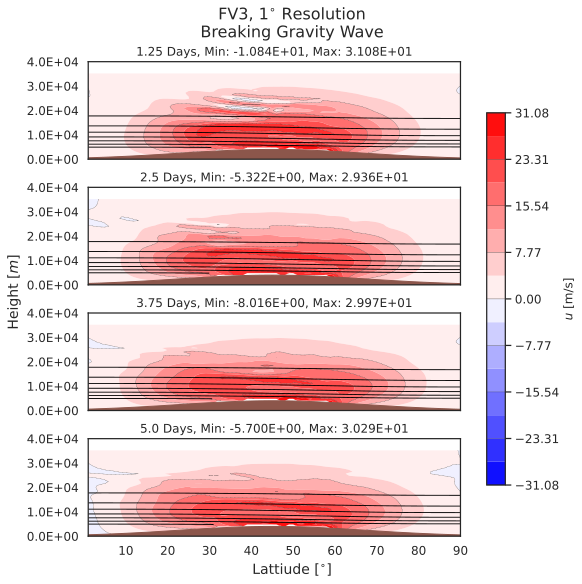

In [129]:
# make the plot
fig, axes = plt.subplots(nrows = len(t_idxs), ncols = 1, 
                         figsize=(8.0, 8.0 * len(t_idxs) / 4.0),
                         sharex = True, 
                         layout = 'constrained')

title_size = 16
label_size = 14
small_size = 12
round_dig = 2

fix_minmax = False

# Feel free to add additional fields
if field_str == 'T':
    field_name: str = 'Temperature'
    cbar_label: str = '$T$ [K]'
    min: float = -2.
    max: float = 5.
    cmap_str: str = "jet"
elif field_str in ['U', 'V', 'OMEGA']:
    if field_str == "U":
      field_name: str = 'Zonal Velocity'
      cbar_label = '$u$ [m/s]'
    elif field_str == "V":
      field_name: str = 'Meridional Velocity'
      cbar_label = '$v$ [m/s]'
    elif field_str == "OMEGA":
      field_name: str = 'Omega'
      cbar_label = '$\omega$ [Pa/s]'
    min = -1.5
    max = 0.6
    cmap_str: str = "bwr"
elif field_str == 'div':
    field_name: str = "Horizontal Divergence"
    cbar_label = '$\sigma$ [1/s]'
    round_dig = 6
    cmap_str: str = "bwr"

if field_str in ["T"]:
  field_max: float = np.nanmax(field)
  field_min: float = np.nanmin(field)
else:
  field_max: float = np.nanmax(np.abs(field))
  field_min: float = -field_max

# Colorbar
n_cbarlevels: int = 17
n_cbarticks: int = 9

cbarlevels: np.ndarray = np.linspace(field_min, field_max, n_cbarlevels)
cbarticks: np.ndarray = np.linspace(field_min, field_max, n_cbarticks)

if ((-1e-10 > field_min) and (1e-10 < field_max)):
    if fix_minmax:
        norm = MidpointNormalize(midpoint = 0, vmin = min, vmax = max)
    else:
        norm = MidpointNormalize(midpoint = 0, vmin = field_min, vmax = field_max)
elif (field_min < 1e-10):
    if (fix_minmax):
        norm = colors.Normalize(vmin=min, vmax=max)
    else:
        norm = colors.Normalize(vmin=0, vmax= field_max)
else:
    if (fix_minmax):
        norm = colors.Normalize(vmin=min, vmax=max)
    else:
        norm = colors.Normalize(vmin = field_min, vmax = field_max)

if fix_minmax:
    levels = 17
    levels = np.mgrid[min:max:levels*1j]
else:
    levels = 15

for ind, ax in enumerate(np.ravel(axes)):
    if fix_minmax:
        ctf = ax.contourf(xaxis_slice, height_levs, field[ind], 
                          levels = cbarlevels, cmap = cmap_str, norm = norm,
                          extend = 'both')
    else:
        ctf = ax.contourf(xaxis_slice, height_levs, field[ind], 
                              levels = cbarlevels, cmap = cmap_str, norm = norm)
    ctf2 = ax.contour(xaxis_slice, height_levs, field[ind], ctf, levels = cbarticks,
                      colors = "black", linewidths = 0.25, linestyles = "dashed")

    if pressure_contour:
        nan_lev_mask: np.ndarray = np.any(np.isnan(pressure_interp[ind]), axis = 1)
        ax.contour(xaxis_slice, height_levs[~nan_lev_mask], pressure_interp[ind, ~nan_lev_mask, :], 
                   colors = 'black', linewidths = 0.9, linestyles = "solid", levels = 7)
    if pot_temp_contour:
        nan_lev_mask: np.ndarray = np.any(np.isnan(potential_temperature_interp[ind]), axis = 1)
        ax.contour(xaxis_slice, height_levs[~nan_lev_mask], potential_temperature_interp[ind, ~nan_lev_mask, :], 
                   colors = 'black', linewidths = 0.9, linestyles = "solid", levels = 7)

    ax.fill_between(xaxis_slice, heights, color = 'tab:brown', zorder = 2) # Mountain overlay

    ax.tick_params(axis = 'both', labelsize = small_size)

    yticks = ax.get_yticks()
    ax.set_yticks(yticks, ["{:1.1E}".format(yticks[ii]) for ii in range(yticks.size)])

    day_str: str = "{} Days".format(ncts[t_idxs[ind]])
    min_str: str = "Min: {:1.3E}".format(np.nanmin(field[ind]))
    max_str: str = "Max: {:1.3E}".format(np.nanmax(field[ind]))
    title_str: str = day_str + ", " + min_str + ", " + max_str
    ax.set_title(title_str)

    ax.set_ylim([height_bot, height_top])

cbar = plt.colorbar(ctf, ax = axes, fraction = 0.05 * len(t_idxs) / 4.0)
cbar.set_label(label = cbar_label, size = small_size)
cbar.ax.tick_params(labelsize = small_size)
cbar.ax.set_yticks(cbarticks)
cbar.add_lines(ctf2)

if lat_lon_flag == "lon":
    supxlabel: str = r"Longitude $\left[ ^{\circ} \right]$"
else:
    supxlabel: str = r"Lattiude $\left[ ^{\circ} \right]$"
supylabel: str = r"Height $\left[ m \right]$"
fig.supylabel(supylabel, size = label_size)
fig.supxlabel(supxlabel, size = label_size)


res_str: str = r"$1^{\circ}$ Resolution"
test_case_name: str = "Breaking Gravity Wave"
suptitle_str: str = model_name + ", " + res_str + "\n" + test_case_name
fig.suptitle(suptitle_str, size = title_size)

plot_file_name: str = field_str + ".png"
plot_file_path: str = os.path.join(out_dir_path, plot_file_name)
plt.savefig(plot_file_path, dpi = 300)